## Импорт библиотек

In [105]:
pip install jupyter_contrib_nbextensions

     ---------------------------------------- 0.0/23.5 MB ? eta -:--:--
     ---------------------------------------- 0.3/23.5 MB ? eta -:--:--
     - -------------------------------------- 0.8/23.5 MB 2.2 MB/s eta 0:00:11
     - -------------------------------------- 1.0/23.5 MB 2.1 MB/s eta 0:00:11
     -- ------------------------------------- 1.3/23.5 MB 2.2 MB/s eta 0:00:11
     --- ------------------------------------ 1.8/23.5 MB 1.9 MB/s eta 0:00:12
     --- ------------------------------------ 2.1/23.5 MB 1.8 MB/s eta 0:00:12
     ---- ----------------------------------- 2.4/23.5 MB 1.7 MB/s eta 0:00:13
     ---- ----------------------------------- 2.6/23.5 MB 1.7 MB/s eta 0:00:13
     ---- ----------------------------------- 2.9/23.5 MB 1.6 MB/s eta 0:00:14
     ----- ---------------------------------- 3.1/23.5 MB 1.5 MB/s eta 0:00:14
     ----- ---------------------------------- 3.4/23.5 MB 1.5 MB/s eta 0:00:14
     ----- ---------------------------------- 3.4/23.5 MB 1.5 MB/s

  DEPRECATION: Building 'jupyter_contrib_nbextensions' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'jupyter_contrib_nbextensions'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'jupyter_contrib_core' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'jupyter_contrib_core'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new 

In [2]:
import pandas as pd
import tabulate
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

## Базовые операции с DataFrame

### Первое знакомство с данными

In [3]:
#Загрузите данные из CSV файла
df = pd.read_csv('D:\\work\\DQ\\tested.csv', sep=',')

In [3]:
#Выведите первые 5 строк
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
#Выведите информацию о DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


|**Variable**|**Definition**|**Key**|
|:---|:---|:---|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex| |	
|Age|Age in years| |
|sibsp|# of siblings / spouses aboard the Titanic| |
|parch|# of parents / children aboard the Titanic| |
|ticket|Ticket number| |
|fare|Passenger fare| |
|cabin|Cabin number| |
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

In [7]:
#Выведите основные статистические характеристики
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [21]:
#Выведите матрицу корреляций
continuous_columns = ['PassengerId','Survived','Pclass','Age','SibSp','Parch','Fare']
df[continuous_columns].corr(method='pearson')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.023245,-0.026751,-0.031447,0.003818,0.043080,0.008211
Survived,-0.023245,1.000000,-0.108615,0.008035,0.099943,0.159120,0.191514
Pclass,-0.026751,-0.108615,1.000000,-0.467853,0.001087,0.018721,-0.577147
Age,-0.031447,0.008035,-0.467853,1.000000,-0.071197,-0.043731,0.347105
SibSp,0.003818,0.099943,0.001087,-0.071197,1.000000,0.306895,0.171539
Parch,0.043080,0.159120,0.018721,-0.043731,0.306895,1.000000,0.230046
Fare,0.008211,0.191514,-0.577147,0.347105,0.171539,0.230046,1.000000


## Анализ и фильтрация данных

### Простая фильтрация

In [14]:
#Найдите всех пассажиров первого класса
df[df['Pclass']==1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,903,0,1,"Jones, Mr. Charles Cresson",male,46.0,0,0,694,26.0000,NaN,S
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,1,0,W.E.P. 5734,61.1750,E31,S
20,912,0,1,"Rothschild, Mr. Martin",male,55.0,1,0,PC 17603,59.4000,NaN,C
22,914,1,1,"Flegenheim, Mrs. Alfred (Antoinette)",female,NaN,0,0,PC 17598,31.6833,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
403,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.0,0,0,113059,47.1000,NaN,S
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C
407,1299,0,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q


In [10]:
#Найдите всех выживших женщин
df.query("(Sex=='female') & (Survived==1)")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,1,3,"Peacock, Miss. Treasteall",female,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
410,1302,1,3,"Naughton, Miss. Hannah",female,NaN,0,0,365237,7.7500,NaN,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,NaN,S


In [13]:
#Найдите пассажиров младше 18 лет
df[(df['Pclass']==1) & (df['Age']<18)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
64,956,0,1,"Ryerson, Master. John Borie",male,13.0,2,2,PC 17608,262.375,B57 B59 B63 B66,C
196,1088,0,1,"Spedden, Master. Robert Douglas",male,6.0,0,2,16966,134.500,E34,C
403,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.0,0,0,113059,47.100,NaN,S


### Агрегатные функции

In [22]:
#Каков средний возраст пассажиров?
age_mean = df['Age'].mean()
fare_min = df['Fare'].min()
fare_max = df['Fare'].max()

print(f'Средний возраст - {age_mean:.1f}')
print(f'Минимальная цена билета - {fare_min:.1f}')
print(f'Максимальная цена билета - {fare_max:.1f}')

Средний возраст - 30.3
Минимальная цена билета - 0.0
Максимальная цена билета - 512.3


In [21]:
#Сколько всего пассажиров было в каждом классе?
df.groupby(by=['Pclass'])['PassengerId'].count()

Pclass
1    107
2     93
3    218
Name: PassengerId, dtype: int64

In [33]:
#Какой была минимальная и максимальная цена билета?
pd.pivot_table(
    df,
    values=['Age', 'Fare', 'Survived', 'PassengerId'],
    index=['Pclass'],
    aggfunc={'Age': {'mean','min'}, 'Fare': {'min','mean','max'}, 'Survived': 'mean', 'PassengerId':'count'},
    fill_value=0
)

Age            Fare                    PassengerId  Survived
             mean   min       max       mean     min       count      mean
Pclass                                                                    
1       40.918367  6.00  512.3292  94.280297  0.0000         107  0.467290
2       28.777500  0.92   73.5000  22.202104  9.6875          93  0.322581
3       24.027945  0.17   69.5500  12.459678  3.1708         218  0.330275

### Анализ выживаемости

In [37]:
#Сколько всего человек выжило?
print('Выжило', df['Survived'].sum(), 'человек(а)')

Выжило 152 человек(а)


In [25]:
#Какой процент пассажиров каждого класса выжил?
display(Markdown('Процент выживших пассажиров в разрезе классов кают'))
s = (df.groupby(by=['Pclass'])['Survived'].mean().round(decimals=2)*100).astype('int')
display(Markdown(s.rename('Suvived ratio').to_markdown()))

Процент выживших пассажиров в разрезе классов кают

|   Pclass |   Suvived ratio |
|---------:|----------------:|
|        1 |              47 |
|        2 |              32 |
|        3 |              33 |

In [74]:
#Каков был процент выживаемости среди мужчин и женщин?
display(Markdown('Процент выживших пассажиров в разрезе пола'))
s = (df.groupby(by=['Sex'])['Survived'].mean().round(decimals=2)*100).astype('int')
display(Markdown(s.rename('Suvived ratio').to_markdown()))

Процент выживших пассажиров в разрезе пола

| Sex    |   Suvived ratio |
|:-------|----------------:|
| female |             100 |
| male   |               0 |

## Более сложные задания

### Работа с пропущенными значениями

In [48]:
#В каких столбцах больше всего пропущенных значений?
df.isna().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

In [27]:
#Создайте новый столбец, указывающий, был ли возраст заполнен или нет
df['is_Aged'] = ~df['Age'].isna()

In [28]:
#Заполните пропущенные значения в возрасте медианным значением
age_med = df['Age'].median()
df['Age'] = df['Age'].fillna(age_med)
df.query("is_Aged == 0")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_Aged


### Группировка данных

In [85]:
#Найдите средний возраст пассажиров по классам
df.groupby(by=['Pclass'])['Age'].mean()

Pclass
1    39.747664
2    28.681935
3    25.009541
Name: Age, dtype: float64

In [86]:
#Посчитайте среднюю стоимость билета для выживших и погибших
df.groupby(by=['Survived'])['Fare'].mean()

Survived
0    27.527877
1    49.747699
Name: Fare, dtype: float64

In [87]:
#Сгруппируйте по полу и классу, посчитайте количество выживших
df.groupby(by=['Sex','Pclass'])['Survived'].sum()

Sex     Pclass
female  1         50
        2         30
        3         72
male    1          0
        2          0
        3          0
Name: Survived, dtype: int64

### Создание новых признаков

In [8]:
# Создайте столбец 'AgeGroup' (ребенок, взрослый, пожилой)
conditions = [
    (df['Age'] <= 17),
    (df['Age'] > 17) & (df['Age'] <= 59),
    (df['Age'] > 59)
]
values = ['ребенок', 'взрослый', 'пожилой']
df['AgeGroup'] = np.select(conditions, values, default='Unknown')

print(df.groupby(by=['AgeGroup'])['PassengerId'].count())

AgeGroup
взрослый    363
пожилой      14
ребенок      41
Name: PassengerId, dtype: int64


In [9]:
# Создайте столбец 'AgeGroup' (ребенок, взрослый, пожилой)
def get_age_group(row):
    
    if 0 < row['Age'] <= 17:
        return 'ребенок'
    elif row['Age'] <= 59:
        return 'взрослый'
    else:
        return 'пожилой'
        
df['AgeGroup'] = df.apply(get_age_group, axis=1)
print(df.groupby(by=['AgeGroup'])['PassengerId'].count())

AgeGroup
взрослый    363
пожилой      14
ребенок      41
Name: PassengerId, dtype: int64


In [10]:
# Создайте столбец 'FamilySize' на основе SibSp и Parch
df['RelativesSize'] = df['SibSp'] + df['Parch']

print(df.groupby(by=['RelativesSize'])['PassengerId'].count())

RelativesSize
0     253
1      74
2      57
3      14
4       7
5       3
6       4
7       2
10      4
Name: PassengerId, dtype: int64


In [11]:
# Создайте столбец 'IsAlone' (путешествовал один или с семьей)
df['isAlone'] = ~df['RelativesSize'].astype('bool')

print(df.groupby(by=['isAlone','RelativesSize'])['PassengerId'].count())

isAlone  RelativesSize
False    1                 74
         2                 57
         3                 14
         4                  7
         5                  3
         6                  4
         7                  2
         10                 4
True     0                253
Name: PassengerId, dtype: int64


### Визуальный анализ

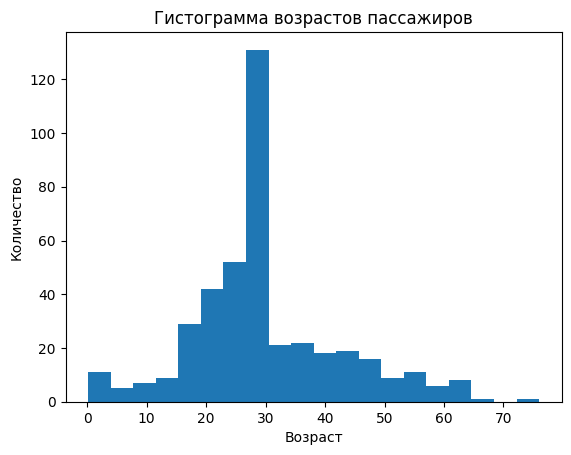

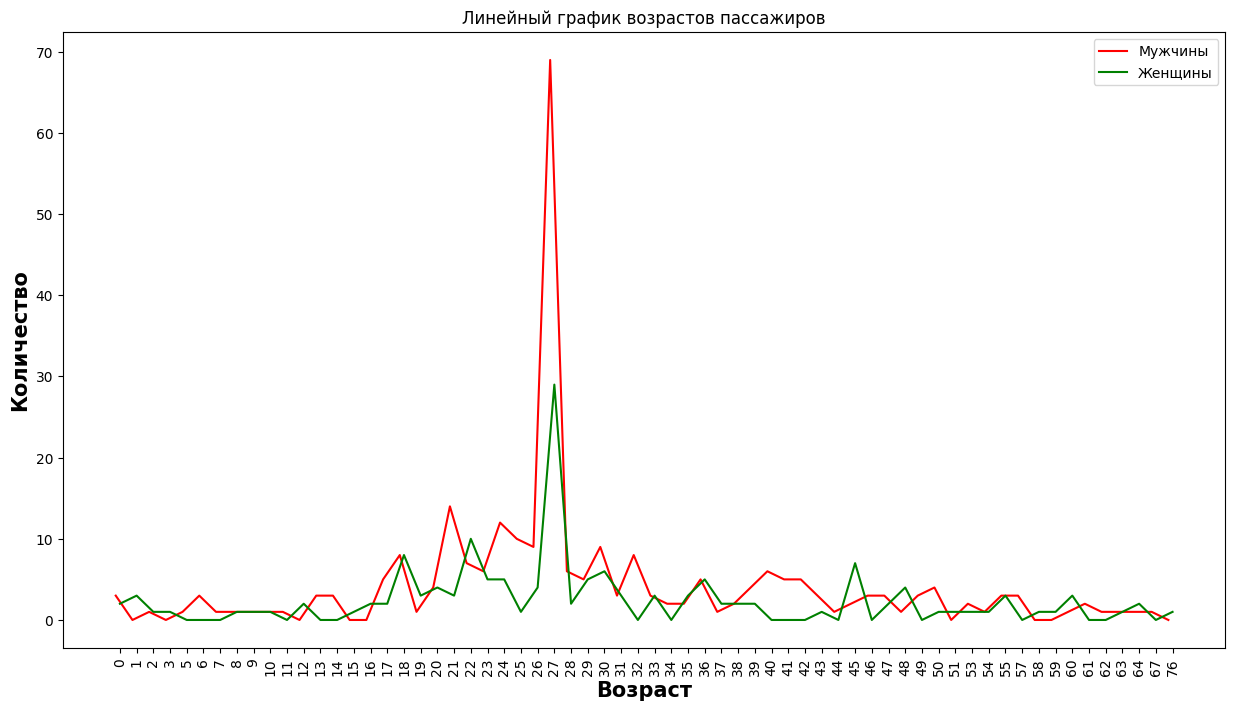

In [33]:
# Постройте гистограмму возрастов пассажиров

# Горизонтальная с одним графиком
age_group = df.groupby(by='Age')['PassengerId'].count()
plt.hist(df['Age'], bins=20)
plt.title('Гистограмма возрастов пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

# Вертикальная с двумя графиками
age_group_male = df.astype({'Age': 'int'}).query("Sex == 'male'").groupby(by=['Age'])['PassengerId'].count()
age_group_female = df.astype({'Age': 'int'}).query("Sex == 'female'").groupby(by=['Age'])['PassengerId'].count()

age_group_index = np.unique(list(age_group_male.index) + list(age_group_female.index))

df_age_sex = pd.merge(
    pd.DataFrame(index=age_group_index),
    pd.DataFrame(age_group_male.values, index=age_group_male.index, columns=['Male']),
    left_index=True,
    right_index=True,
    how='left'
)

df_age_sex_final = pd.merge(
    df_age_sex,
    pd.DataFrame(age_group_female.values, index=age_group_female.index, columns=['Female']),
    left_index=True,
    right_index=True,
    how='left'
)
df_age_sex_final.fillna(0, inplace=True)
df_age_sex_final['Male'] = df_age_sex_final['Male'].astype('int')
df_age_sex_final['Female'] = df_age_sex_final['Female'].astype('int')
barWidth = 0.25
fig = plt.subplots(figsize=(15, 8)) 

br1 = np.arange(len(df_age_sex_final.index)) 
br2 = [x + barWidth for x in br1]

plt.plot(br1, df_age_sex_final.Male.values, color ='r', label ='Мужчины') 
plt.plot(br2, df_age_sex_final.Female.values, color ='g', label ='Женщины')

plt.title('Линейный график возрастов пассажиров')
plt.xlabel('Возраст', fontweight ='bold', fontsize = 15) 
plt.xticks(rotation=90)
plt.ylabel('Количество', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(df_age_sex_final.index))], df_age_sex_final.index)

plt.legend()
plt.show()

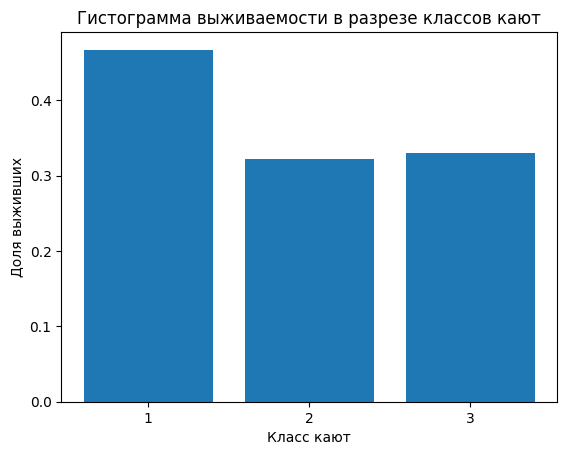

In [48]:
# Создайте bar plot выживаемости по классам
survived_ratio = df.astype({'Pclass': 'str'}).groupby(by=['Pclass'])['Survived'].mean()
plt.bar(survived_ratio.index, survived_ratio.values)
plt.title('Гистограмма выживаемости в разрезе классов кают')
plt.xlabel('Класс кают')
#plt.ylim(0.31,0.35)
#plt.yticks(np.arange(0.31,0.35))
plt.ylabel('Доля выживших')
plt.show()

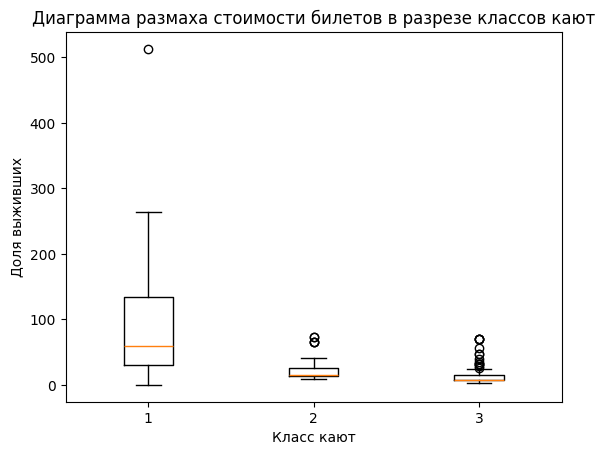

In [47]:
# Постройте box plot стоимости билетов по классам
plt.boxplot(
    [
        df.query("Pclass == 1")['Fare'],
        df.query("Pclass == 2")['Fare'],
        df[~df['Fare'].isna()].query("Pclass == 3")['Fare']
    ]
)
plt.title('Диаграмма размаха стоимости билетов в разрезе классов кают')
plt.xlabel('Класс кают')
#plt.ylim(0,200)
plt.ylabel('Доля выживших')
plt.show()

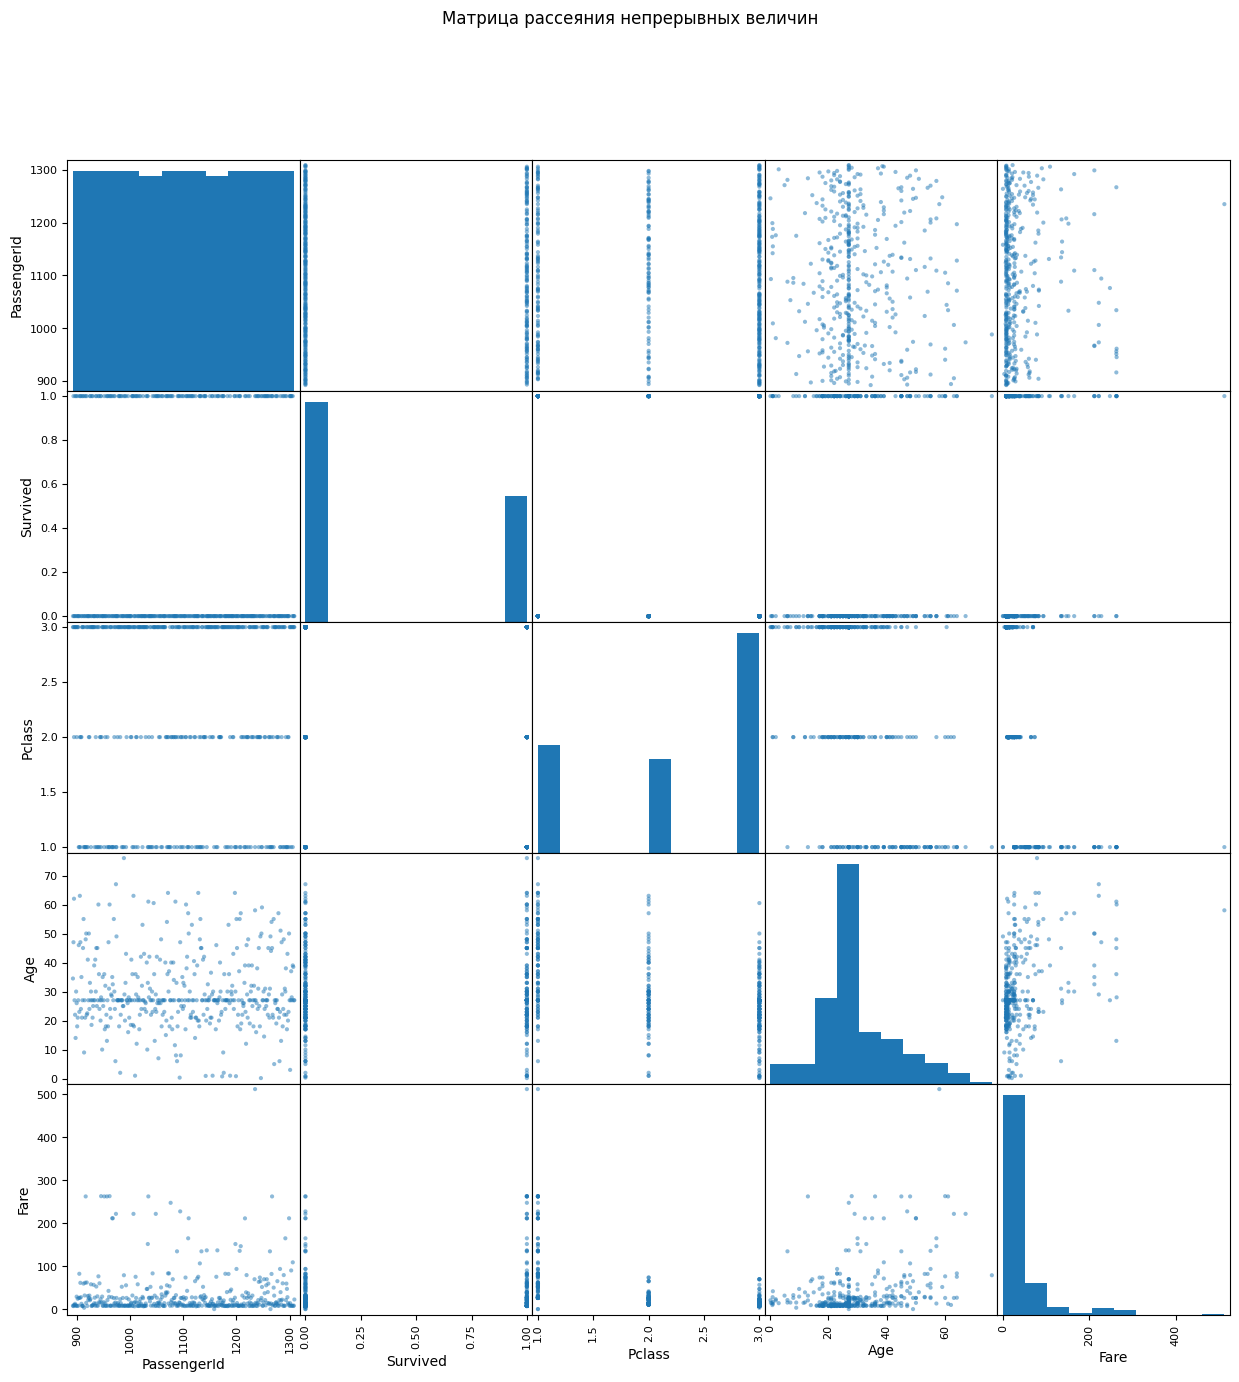

In [32]:
# Матрица рассеяния непрерывных величин
continuous_columns = [
    'PassengerId'
    ,'Survived'
    ,'Pclass'
    ,'Age'
    #,'SibSp'
    #,'Parch'
    ,'Fare'
]
df_scatter_matrix = scatter_matrix(df[continuous_columns], figsize=(15,15))
plt.suptitle('Матрица рассеяния непрерывных величин')
plt.show()

### Поиск аномалий и интересных кейсов

In [107]:
# Найдите пассажиров с самой высокой стоимостью билета
df.sort_values(by=['Fare'], ascending=False).head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_Aged,AgeGroup,RelativesSize,isAlone
343,1235,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C,True,взрослый,1,False
69,961,1,1,"Fortune, Mrs. Mark (Mary McDougald)",female,60.0,1,4,19950,263.0000,C23 C25 C27,S,True,пожилой,5,False
53,945,1,1,"Fortune, Miss. Ethel Flora",female,28.0,3,2,19950,263.0000,C23 C25 C27,S,True,взрослый,5,False
142,1034,0,1,"Ryerson, Mr. Arthur Larned",male,61.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,True,пожилой,4,False
24,916,1,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.0,1,3,PC 17608,262.3750,B57 B59 B63 B66,C,True,взрослый,4,False


<Axes: title={'center': 'Анализ выживаемости семей'}, xlabel='Кол-во в семье', ylabel='Доля выживших'>

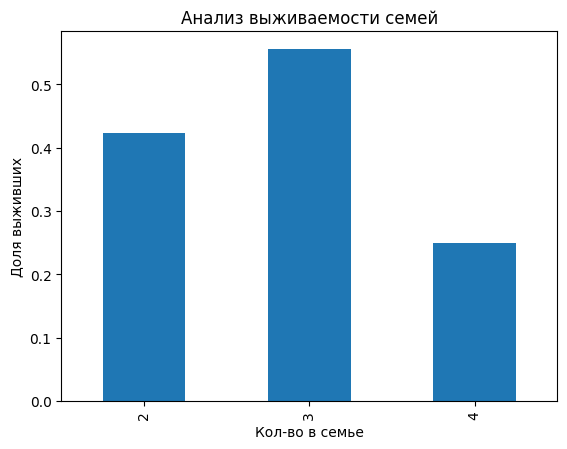

In [139]:
# Найдите семьи (с одинаковой фамилией) и проанализируйте их выживаемость
df['Surname'] = df['Name'].str.split(',')
df['Surname'] = df['Surname'].str[0]

families_survivings = pd.pivot_table(
    df,
    values=['PassengerId', 'Survived'],
    index=['Surname'],
    aggfunc={'PassengerId': 'count', 'Survived': 'mean'},
    fill_value=0
)
families_survivings = families_survivings.query("PassengerId > 1")
families_survivings.columns = ['FamilyCount','AvgSurvived']
families_survivings_group = families_survivings.groupby(by='FamilyCount')['AvgSurvived'].mean()

families_survivings_group.plot.bar(title='Анализ выживаемости семей', xlabel='Кол-во в семье', ylabel='Доля выживших')

In [30]:
# Найдите пассажиров, которые путешествовали бесплатно
df[(df['Fare']==0) | (df['Fare'].isna())]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,is_Aged
152,1044,0,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,True
266,1158,0,1,"Chisholm, Mr. Roderick Robert Crispin",male,27.0,0,0,112051,0.0,NaN,S,True
372,1264,0,1,"Ismay, Mr. Joseph Bruce",male,49.0,0,0,112058,0.0,B52 B54 B56,S,True
